# 3-axis slicer

## Load STL

4292 triangles
Bounding box: [-15.       -14.978001   0.      ] to [50.76467  14.978001 86.222084]


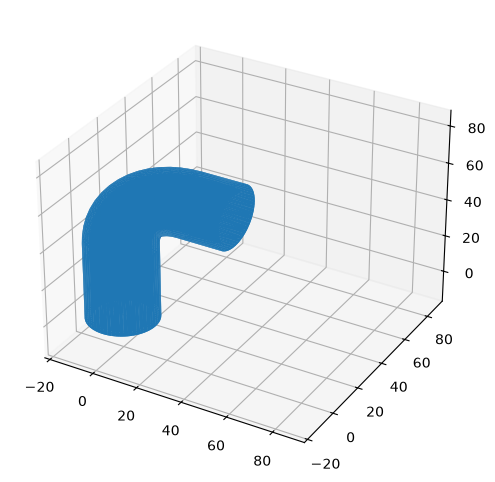

In [148]:
from stl import mesh
from matplotlib import pyplot
from mpl_toolkits import mplot3d
import numpy as np

file = 'stl/pipe.stl'

model = mesh.Mesh.from_file(file)

# Inspect
print(f'{len(model)} triangles')
print(f'Bounding box: {model.min_} to {model.max_}')

figure = pyplot.figure(figsize=(8, 6))
axes = figure.add_subplot(projection='3d')

axes.add_collection3d(mplot3d.art3d.Poly3DCollection(model.vectors))
scale = model.points.flatten()
axes.auto_scale_xyz(scale, scale, scale)


pyplot.show()


## Parameters

In [149]:
LAYER_HEIGHT = 1
WALL_LINES = 3
WALL_THICKNESS = 0.4
OUTER_WALL_OFFSET = WALL_THICKNESS / 2
INFILL = 0.4

## Slice the model

0 / 86 slices generated.
1 / 86 slices generated.
2 / 86 slices generated.
3 / 86 slices generated.
4 / 86 slices generated.
5 / 86 slices generated.
6 / 86 slices generated.
7 / 86 slices generated.
8 / 86 slices generated.
9 / 86 slices generated.
10 / 86 slices generated.
11 / 86 slices generated.
12 / 86 slices generated.
13 / 86 slices generated.
14 / 86 slices generated.
15 / 86 slices generated.
16 / 86 slices generated.
17 / 86 slices generated.
18 / 86 slices generated.
19 / 86 slices generated.
20 / 86 slices generated.
21 / 86 slices generated.
22 / 86 slices generated.
23 / 86 slices generated.
24 / 86 slices generated.
25 / 86 slices generated.
26 / 86 slices generated.
27 / 86 slices generated.
28 / 86 slices generated.
29 / 86 slices generated.
30 / 86 slices generated.
31 / 86 slices generated.
32 / 86 slices generated.
33 / 86 slices generated.
34 / 86 slices generated.
35 / 86 slices generated.
36 / 86 slices generated.
37 / 86 slices generated.
38 / 86 slices generat

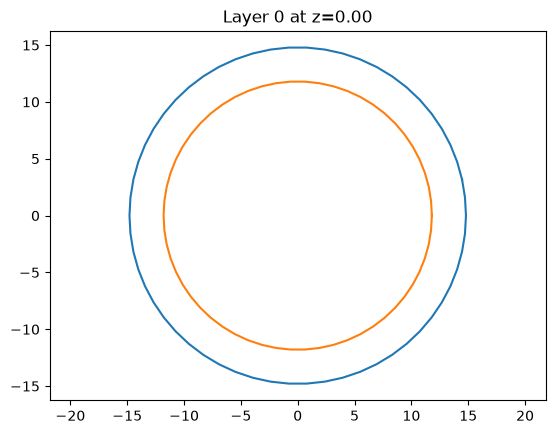

In [150]:
import meshcut
from shapely.geometry import LineString, Polygon
from shapely import union
from shapely.ops import polygonize, unary_union

def offset_contours(contours, offset_distance, join_style="mitre"):
    """Return all filled contour rings after one inward material offset."""
    lines = []
    z = None

    for contour in contours:
        points = np.asarray(
            contour.get_points() if hasattr(contour, "get_points") else contour
        )
        if points.ndim != 2 or points.shape[0] < 4 or points.shape[1] < 2:
            raise ValueError("Each contour must contain at least four 2D/3D points.")

        xy = points[:, :2]
        if not np.allclose(xy[0], xy[-1]):
            xy = np.vstack([xy, xy[0]])

        line = LineString(xy)
        if not line.is_simple:
            raise ValueError("Contours must not self-intersect.")
        lines.append(line)
        if z is None and points.shape[1] >= 3:
            z = points[0, 2]

    if not lines:
        return []

    # Polygonize the complete linework, then keep faces covered by an odd
    # number of input contours: material, hole, material, and so on.
    ring_polygons = [Polygon(line) for line in lines]
    faces = list(polygonize(unary_union(lines)))
    material_faces = [
        face for face in faces
        if sum(ring.covers(face.representative_point()) for ring in ring_polygons) % 2 == 1
    ]
    if not material_faces:
        return []

    material = unary_union(material_faces)
    offset = material.buffer(-offset_distance, join_style=join_style)
    if offset.is_empty:
        return []

    polygons = [offset] if offset.geom_type == "Polygon" else list(offset.geoms)
    curves = []
    for polygon in polygons:
        for ring in [polygon.exterior, *polygon.interiors]:
            points = np.asarray(ring.coords[:-1])
            if z is not None:
                points = np.column_stack([points, np.full(points.shape[0], z)])
            curves.append(points)

    return curves

slices = []

class Slice:
    def __init__(self):
        self.contours = []

        self.layer_number = len(slices)
        self.z_height = self.layer_number * LAYER_HEIGHT

    def display_slice(self):
        for contour in self.contours:
            # collapse to 2D by dropping the z-coordinate
            line = contour.get_points()[:, :2]
            # plot in 2D
            pyplot.plot(line[:, 0], line[:, 1])

        pyplot.title(f'Layer {self.layer_number} at z={self.z_height:.2f}')
        pyplot.axis('equal')
        pyplot.show()

    def get_contours(self):
        return self.contours

    def add_contour(self, contour):
        self.contours.append(contour)

class Contour:
    def __init__(self, points, type, index = None):
        self.points = np.asarray(points)

        # Walls are closed loops; infill is an open toolpath.
        if type == "wall" and not np.allclose(self.points[0], self.points[-1]):
            self.points = np.vstack([self.points, self.points[0]])

        self.type = type
        self.index = index

        # find the slice it belongs to based on the z-coordinate of the first point
        self.slice_index = int(self.points[0][2] / LAYER_HEIGHT)
        # add the contour to the appropriate slice
        slices[self.slice_index].add_contour(self)

    def get_points(self):
        return self.points

# Extract unique vertices and indexed faces so meshcut can follow shared edges.
verts, inverse = np.unique(model.vectors.reshape(-1, 3), axis=0, return_inverse=True)
faces = inverse.reshape(-1, 3)

for i in range(0, int((model.max_[2] - model.min_[2]) / LAYER_HEIGHT)):
    slices.append(Slice())

    # Define a cutting plane
    plane_orig = np.array([0.0, 0.0, i * LAYER_HEIGHT])
    plane_normal = np.array([0.0, 0.0, 1.0])

    # Compute the cross-section
    polylines = meshcut.cross_section(verts, faces, plane_orig, plane_normal)

    # polylines now contains a list of line segments representing the intersection
    for line in polylines:
        # apply a wall offset to the contour
        offset_lines = offset_contours([line], OUTER_WALL_OFFSET, join_style="mitre")

        for offset_line in offset_lines:
            Contour(offset_line, type='wall', index=0)

    print(f"{i} / {int((model.max_[2] - model.min_[2]) / LAYER_HEIGHT)} slices generated.")

print(len(slices), "slices generated.")
slices[0].display_slice()

## Add conecentric contours for each contour in the layer (Inner walls)

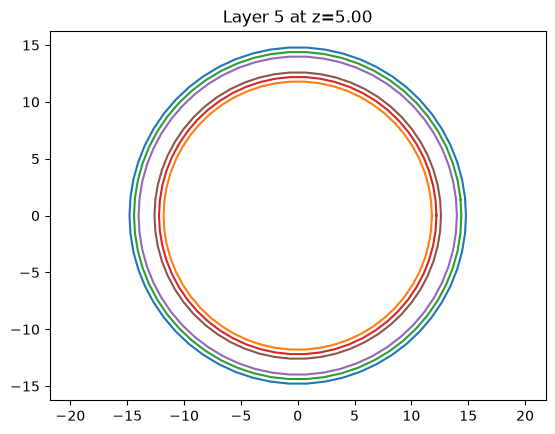

In [151]:
for slice in slices:
    contours = [
        contour for contour in slice.get_contours()
        if contour.type == "wall" and contour.index == 0
    ]
    #print(len(contours), "original contours in first slice.")

    for n in range(1, WALL_LINES):
        offset_distance = n * WALL_THICKNESS
        offset_curves = offset_contours(contours, offset_distance)
        for curve in offset_curves:
            Contour(curve, type="wall", index=n)

slices[5].display_slice()

## Infill

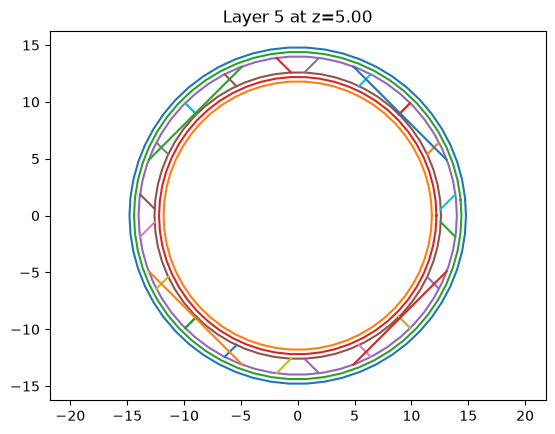

In [159]:
# Find the region enclosed by the wall with the highest index.
#slice = slices[20]

for slice in slices:

    # Remove infill from an earlier execution so rerunning this cell replaces it.
    slice.contours = [
        contour for contour in slice.get_contours()
        if contour.type != "infill"
    ]

    innermost_walls = [
        contour for contour in slice.get_contours()
        if contour.type == "wall" and contour.index == WALL_LINES - 1
    ]

    # Generate a 45-degree grid pattern.
    infill_pattern = []
    for i in range(-100, 100, max(int((1 - INFILL) * 10), 1)):
        infill_pattern.append(LineString([(100, i), (i, 100)]))
        infill_pattern.append(LineString([(-i, -100), (-100, -i)]))

        infill_pattern.append(LineString([(-100, i), (-i, 100)]))
        infill_pattern.append(LineString([(i, -100), (100, -i)]))

    # Polygonize the innermost wall boundaries and use even-odd filling.
    # This keeps an inner contour empty, producing an annulus instead of filling it.
    wall_lines = [
        LineString(contour.get_points()[:, :2])
        for contour in innermost_walls
    ]
    wall_polygons = [Polygon(line) for line in wall_lines]
    wall_faces = list(polygonize(unary_union(wall_lines)))
    innermost_wall_region = unary_union([
        face for face in wall_faces
        if sum(
            polygon.covers(face.representative_point())
            for polygon in wall_polygons
        ) % 2 == 1
    ])

    # Clip each source line separately so crossings do not split toolpaths.
    for pattern_line in infill_pattern:
        clipped = pattern_line.intersection(innermost_wall_region)
        if clipped.is_empty:
            continue

        if clipped.geom_type == "LineString":
            clipped_lines = [clipped]
        elif clipped.geom_type == "MultiLineString":
            clipped_lines = list(clipped.geoms)
        elif clipped.geom_type == "GeometryCollection":
            clipped_lines = [
                geom for geom in clipped.geoms
                if geom.geom_type == "LineString"
            ]
        else:
            clipped_lines = []

        for line in clipped_lines:
            if line.is_empty or len(line.coords) < 2:
                continue
            points = np.column_stack([
                np.asarray(line.coords),
                np.full(len(line.coords), slice.z_height),
            ])
            Contour(points, type="infill", index=0)

slices[5].display_slice()